In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import json
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output
import matplotlib.pyplot as plt
import pyautogui

In [2]:
SCREEN_WIDTH, SCREEN_HEIGHT = pyautogui.size()

In [3]:
# Define the Neural Network model
class GazeToMouseModel(nn.Module):
    def __init__(self):
        super(GazeToMouseModel, self).__init__()
        
        # Input layer (21 input features: iris landmarks, head position, head pose)
        self.fc1 = nn.Linear(9, 128)  # First fully connected layer with 128 neurons
        self.fc2 = nn.Linear(128, 64)  # Second hidden layer with 64 neurons
        self.fc3 = nn.Linear(64, 32)   # Third hidden layer with 32 neurons
        self.fc4 = nn.Linear(32, 2)    # Output layer (2 values for mouse x, y positions)
        
        # Activation function
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))  # Pass through first layer and activation
        x = self.relu(self.fc2(x))  # Pass through second layer and activation
        x = self.relu(self.fc3(x))  # Pass through third layer and activation
        x = self.fc4(x)             # Output layer without activation (regression)
        return x


# Define a custom dataset class
class GazeDataset(Dataset):
    def __init__(self, json_file):
        """
        Args:
            json_file (string): Path to the json file with annotations.
        """
        # Load the data from the JSON file
        with open(json_file, 'r') as f:
            self.data = json.load(f)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the data sample.
        
        Returns:
            A tuple (input_tensor, target_tensor).
        """
        sample = self.data[idx]
        
        # Preprocess the data (use the function we created earlier)
        input_tensor, target_tensor = preprocess_data(sample)
        
        return input_tensor, target_tensor


def preprocess_data(sample):
    """
    Convert a single sample into a tensor of 21 features:
    - Flatten the iris landmarks (4 points per eye, each with x, y coordinates)
    - Include the head position (x, y)
    - Include the head pose (yaw, pitch, roll)
    
    Return a tensor of shape (21,).
    """
    iris_landmarks = sample['pupil_landmarks']
    
    # Flatten the iris landmarks (4 points for each eye, each point has x, y)
    left_iris = [coord for point in iris_landmarks['left_pupil'] for coord in point]
    right_iris = [coord for point in iris_landmarks['right_pupil'] for coord in point]
    
    # Get the head position (x, y)
    head_position = sample['head_position']
    # normalize head position
    normalized_head_position = [
        head_position[0] / SCREEN_WIDTH,
        head_position[1] / SCREEN_HEIGHT
    ]
    
    
    # Normalize the head pose (yaw, pitch, roll) to [0, 1] by scaling the angles
    yaw = sample['head_pose']['yaw']
    pitch = sample['head_pose']['pitch']
    roll = sample['head_pose']['roll']
    
    normalized_head_pose = [
        (yaw + 180) / 360,   # Normalize yaw to [0, 1]
        (pitch + 180) / 360, # Normalize pitch to [0, 1]
        (roll + 180) / 360   # Normalize roll to [0, 1]
    ]  # (3 values)
    
    
    # Combine all features into a single list
    features = left_iris + right_iris + normalized_head_position + normalized_head_pose

    
    # Convert to a PyTorch tensor
    input_tensor = torch.tensor(features, dtype=torch.float32)
    
    # Target mouse position (x, y)
    mouse_x, mouse_y = sample['mouse_position']
    target_tensor = torch.tensor([mouse_x / SCREEN_WIDTH, mouse_y / SCREEN_HEIGHT], dtype=torch.float32)
    
    return input_tensor, target_tensor

In [4]:
# Create the Dataset
json_file = "gaze_data_.json"  # Replace with the path to your json file
dataset = GazeDataset(json_file)

# Create a DataLoader with batch size 32 (for example) and shuffle the data
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Instantiate the model, loss function, and optimizer
model = GazeToMouseModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

In [5]:
print(dataset.__len__())

1457


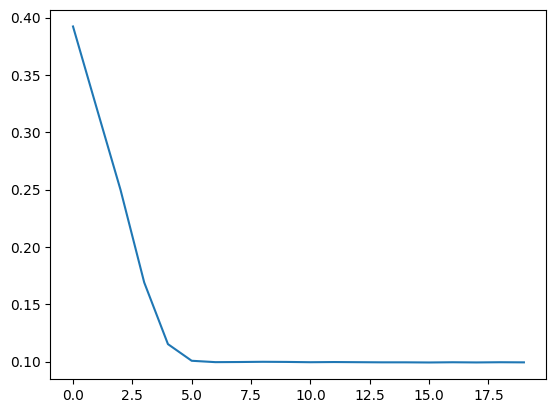

Epoch 20/20, Loss: 0.09929868757076886


In [6]:
# Training loop
num_epochs = 20  # Define how many epochs you want to train for
losses = []  # Keep track of the losses

for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, targets in train_loader:  # train_loader loads batches of (input_tensor, target_tensor)
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Print shapes of outputs and targets to verify
        print(f"Outputs shape: {outputs.shape}, Targets shape: {targets.shape}")
        
        # Calculate the loss
        loss = criterion(outputs, targets)
        
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Track loss
        running_loss += loss.item()
    
    # Save the loss for every epoch
    losses.append(running_loss / len(train_loader))
    # Plot the loss every epoch
    clear_output(True)
    plt.plot(losses)
    plt.show()
    # Print average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader)}")

In [7]:
# Save the model
torch.save(model.state_dict(), 'gaze_to_mouse_model_.pth')